# AI-Based Anomaly Detection for Bytecode VM Performance

This notebook applies machine-learning-based anomaly detection to runtime
performance data collected from a bytecode virtual machine.

The profiler uses StandardScaler for feature normalization and Isolation Forest
to identify unusual runtime executions based on execution, opcode, garbage
collection, and memory-related metrics.

## Notebook Flow

1. Introduction
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Runtime Features
6. Feature Scaling
7. Isolation Forest
8. Detected Anomalies
9. Runtime Visualization
10. Benchmark Analysis
11. Anomalies by Benchmark
12. Model Evaluation
    - Confusion Matrix
13. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_anomalies_v1.csv to dataset_anomalies_v1.csv


In [3]:
df = pd.read_csv("dataset_anomalies_v1.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (160, 13)


,benchmark,input_size,run,compilation_time_ms,execution_time_ms,opcode_executions,gc_count,gc_time_ms,peak_heap_usage_bytes,total_bytes_allocated,total_bytes_freed,anomaly_label,anomaly_score
0,allocation,1000000,1,0.0,703.0,21000019,90300,157.0,1048598,156001626,155999972,-1,-0.120100
1,allocation,1000000,2,0.0,592.0,21000019,90300,109.0,1048598,156001626,155999972,-1,-0.080600
2,allocation,1000000,3,0.0,637.0,21000019,90300,97.0,1048598,156001626,155999972,-1,-0.025590
3,allocation,1000000,4,0.0,633.0,21000019,90300,99.0,1048598,156001626,155999972,-1,-0.022039
4,allocation,1000000,5,0.0,663.0,21000019,90300,127.0,1048598,156001626,155999972,-1,-0.068065


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   benchmark              160 non-null    object 
 1   input_size             160 non-null    int64  
 2   run                    160 non-null    int64  
 3   compilation_time_ms    160 non-null    float64
 4   execution_time_ms      160 non-null    float64
 5   opcode_executions      160 non-null    int64  
 6   gc_count               160 non-null    int64  
 7   gc_time_ms             160 non-null    float64
 8   peak_heap_usage_bytes  160 non-null    int64  
 9   total_bytes_allocated  160 non-null    int64  
 10  total_bytes_freed      160 non-null    int64  
 11  anomaly_label          160 non-null    int64  
 12  anomaly_score          160 non-null    float64
dtypes: float64(4), int64(8), object(1)
memory usage: 16.4+ KB


In [5]:
df.describe()

,input_size,run,compilation_time_ms,execution_time_ms,opcode_executions,gc_count,gc_time_ms,peak_heap_usage_bytes,total_bytes_allocated,total_bytes_freed,anomaly_label,anomaly_score
count,1.600000e+02,160.000000,160.0,160.000000,1.600000e+02,160.000000,160.000000,1.600000e+02,1.600000e+02,1.600000e+02,160.000000,160.000000
mean,8.679722e+05,3.000000,0.0,680.787500,3.610780e+07,3096.281250,4.481250,1.047264e+05,5.417875e+06,5.411272e+06,0.900000,0.216167
std,2.398655e+06,1.418654,0.0,1664.710489,9.138365e+07,15780.854492,21.210823,3.057421e+05,2.726707e+07,2.726802e+07,0.437258,0.100238
min,2.000000e+01,1.000000,0.0,0.000000,2.101700e+04,0.000000,0.000000,1.151000e+03,1.151000e+03,0.000000e+00,-1.000000,-0.120100
25%,1.000000e+03,2.000000,0.0,6.000000,2.250345e+05,0.000000,0.000000,1.341250e+03,1.341250e+03,0.000000e+00,1.000000,0.179716
50%,5.500000e+04,3.000000,0.0,59.000000,2.200033e+06,0.000000,0.000000,1.499500e+03,1.563500e+03,6.400000e+01,1.000000,0.254869
75%,1.000000e+06,4.000000,0.0,426.250000,2.150003e+07,0.000000,0.000000,2.598750e+03,2.726750e+03,1.280000e+02,1.000000,0.291832
max,1.000000e+07,5.000000,0.0,7325.000000,3.881891e+08,90300.000000,157.000000,1.048598e+06,1.560016e+08,1.560000e+08,1.000000,0.307492


## Dataset Overview

The dataset contains runtime observations collected from the bytecode VM.
Each observation contains measurements related to compilation, execution,
opcode activity, garbage collection, and memory usage.

In [6]:
print(f"Number of observations: {len(df)}")
print(f"Number of features: {len(df.columns)}")

Number of observations: 160
Number of features: 13


In [7]:
FEATURES = [
    "compilation_time_ms",
    "execution_time_ms",
    "opcode_executions",
    "gc_count",
    "gc_time_ms",
    "peak_heap_usage_bytes",
    "total_bytes_allocated",
    "total_bytes_freed"
]

X = df[FEATURES]

display(X.head())

,compilation_time_ms,execution_time_ms,opcode_executions,gc_count,gc_time_ms,peak_heap_usage_bytes,total_bytes_allocated,total_bytes_freed
0,0.0,703.0,21000019,90300,157.0,1048598,156001626,155999972
1,0.0,592.0,21000019,90300,109.0,1048598,156001626,155999972
2,0.0,637.0,21000019,90300,97.0,1048598,156001626,155999972
3,0.0,633.0,21000019,90300,99.0,1048598,156001626,155999972
4,0.0,663.0,21000019,90300,127.0,1048598,156001626,155999972


## Feature Scaling

The runtime metrics have very different numerical ranges. For example,
opcode executions and memory allocation can have values much larger than
execution time.

StandardScaler transforms the features to a common scale before anomaly
detection.

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (160, 8)


In [9]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df["anomaly_label"] = model.fit_predict(X_scaled)
df["anomaly_score"] = model.decision_function(X_scaled)

In [10]:
df["anomaly_label"].value_counts()

,count
anomaly_label,
1,152
-1,8


In [11]:
anomalies = df[df["anomaly_label"] == -1]

print("Detected anomalies:", len(anomalies))

display(anomalies)

Detected anomalies: 8


,benchmark,input_size,run,compilation_time_ms,execution_time_ms,opcode_executions,gc_count,gc_time_ms,peak_heap_usage_bytes,total_bytes_allocated,total_bytes_freed,anomaly_label,anomaly_score
0,allocation,1000000,1,0.0,703.0,21000019,90300,157.0,1048598,156001626,155999972,-1,-0.116304
1,allocation,1000000,2,0.0,592.0,21000019,90300,109.0,1048598,156001626,155999972,-1,-0.083000
2,allocation,1000000,3,0.0,637.0,21000019,90300,97.0,1048598,156001626,155999972,-1,-0.026722
3,allocation,1000000,4,0.0,633.0,21000019,90300,99.0,1048598,156001626,155999972,-1,-0.022145
4,allocation,1000000,5,0.0,663.0,21000019,90300,127.0,1048598,156001626,155999972,-1,-0.063924
6,allocation,100000,2,0.0,154.0,2100019,8481,32.0,1048598,15601626,15598568,-1,-0.002171
9,allocation,100000,5,0.0,110.0,2100019,8481,6.0,1048598,15601626,15598568,-1,-0.010983
155,recursion,35,1,0.0,7325.0,388189144,0,0.0,1151,1151,0,-1,-0.015137


In [12]:
anomalies.sort_values("anomaly_score")

,benchmark,input_size,run,compilation_time_ms,execution_time_ms,opcode_executions,gc_count,gc_time_ms,peak_heap_usage_bytes,total_bytes_allocated,total_bytes_freed,anomaly_label,anomaly_score
0,allocation,1000000,1,0.0,703.0,21000019,90300,157.0,1048598,156001626,155999972,-1,-0.116304
1,allocation,1000000,2,0.0,592.0,21000019,90300,109.0,1048598,156001626,155999972,-1,-0.083000
4,allocation,1000000,5,0.0,663.0,21000019,90300,127.0,1048598,156001626,155999972,-1,-0.063924
2,allocation,1000000,3,0.0,637.0,21000019,90300,97.0,1048598,156001626,155999972,-1,-0.026722
3,allocation,1000000,4,0.0,633.0,21000019,90300,99.0,1048598,156001626,155999972,-1,-0.022145
155,recursion,35,1,0.0,7325.0,388189144,0,0.0,1151,1151,0,-1,-0.015137
9,allocation,100000,5,0.0,110.0,2100019,8481,6.0,1048598,15601626,15598568,-1,-0.010983
6,allocation,100000,2,0.0,154.0,2100019,8481,32.0,1048598,15601626,15598568,-1,-0.002171


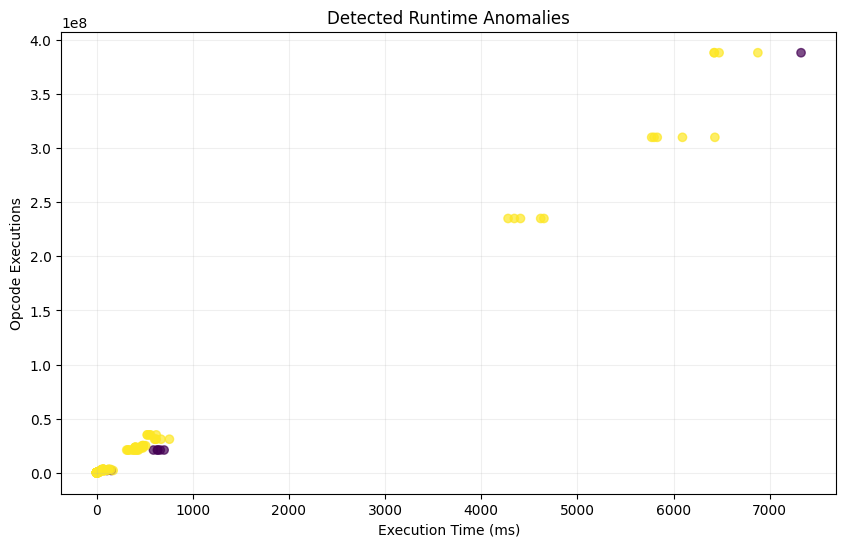

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["execution_time_ms"],
    df["opcode_executions"],
    c=df["anomaly_label"],
    alpha=0.7
)

plt.xlabel("Execution Time (ms)")
plt.ylabel("Opcode Executions")
plt.title("Detected Runtime Anomalies")
plt.grid(True, alpha=0.2)

plt.show()

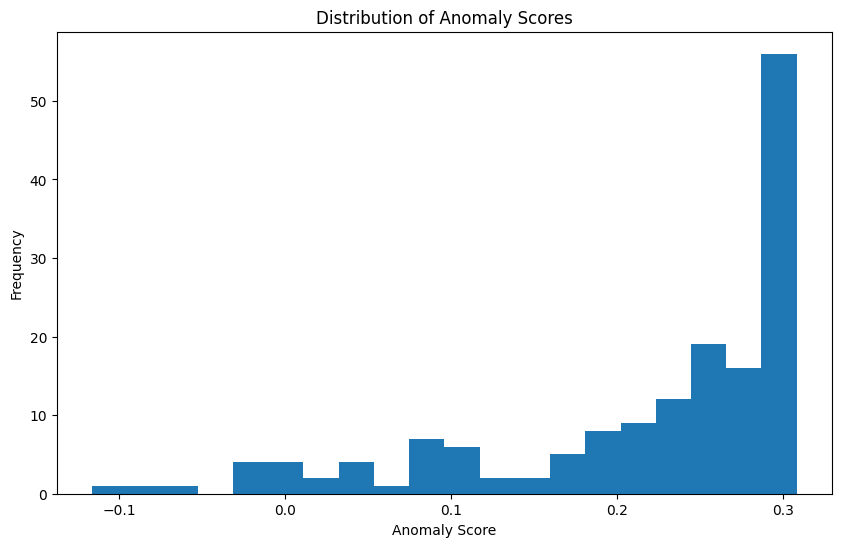

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(df["anomaly_score"], bins=20)

plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Distribution of Anomaly Scores")

plt.show()

In [15]:
df["benchmark"].value_counts()

,count
benchmark,
allocation,20
arithmetic,20
closures,20
functions,20
inheritance,20
loops,20
objects,20
recursion,20


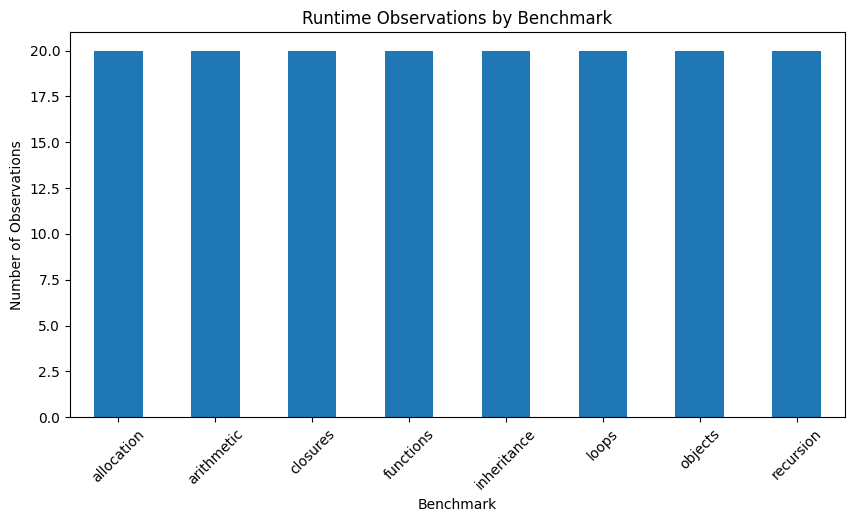

In [16]:
plt.figure(figsize=(10, 5))

df["benchmark"].value_counts().plot(kind="bar")

plt.xlabel("Benchmark")
plt.ylabel("Number of Observations")
plt.title("Runtime Observations by Benchmark")

plt.xticks(rotation=45)
plt.show()

In [17]:
anomaly_by_benchmark = (
    df[df["anomaly_label"] == -1]
    ["benchmark"]
    .value_counts()
)

display(anomaly_by_benchmark)

,count
benchmark,
allocation,7
recursion,1


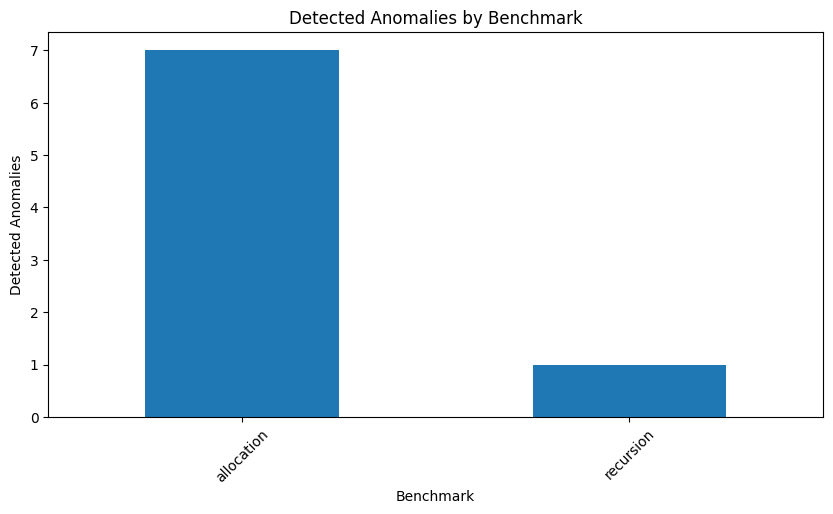

In [18]:
plt.figure(figsize=(10, 5))

anomaly_by_benchmark.plot(kind="bar")

plt.xlabel("Benchmark")
plt.ylabel("Detected Anomalies")
plt.title("Detected Anomalies by Benchmark")

plt.xticks(rotation=45)
plt.show()

## Model Evaluation

The original experiment reports the following evaluation results:

- True Negatives: 148
- False Positives: 2
- False Negatives: 4
- True Positives: 6
- Precision: 75%
- Recall: 60%
- F1-score: 66.7%

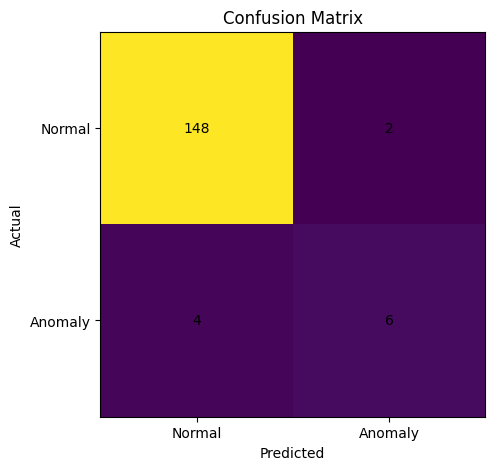

In [19]:
cm = np.array([
    [148, 2],
    [4, 6]
])

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Conclusion

The experiment demonstrates how runtime telemetry from a bytecode virtual
machine can be analyzed using machine learning.

StandardScaler normalizes the heterogeneous runtime metrics, while Isolation
Forest identifies observations exhibiting unusual performance characteristics.

The approach provides an automated method for detecting potentially abnormal
VM executions using execution, opcode, garbage-collection, and memory metrics.